<a href="https://colab.research.google.com/github/pranetha-gif/AIML-Recruitment-2026-Pranetha/blob/main/AIML_Task_AutoMPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== PART A: DATA EXPLORATION ===
Dataset Shape: 398 rows, 9 columns

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None

--- Basic Descriptive Statistics ---
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.42462

/tmp/ipykernel_1112/2917254409.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(hp_median, inplace=True)


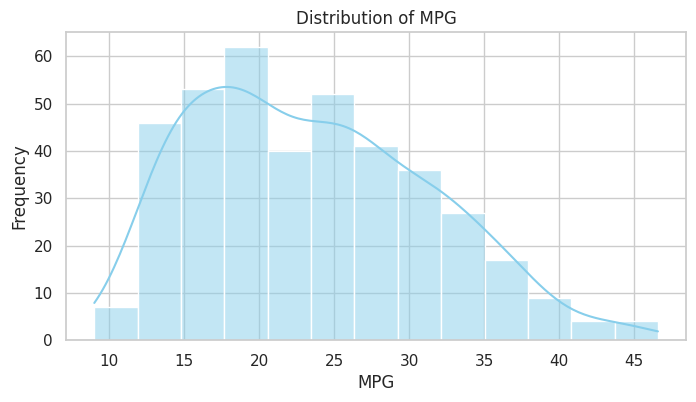

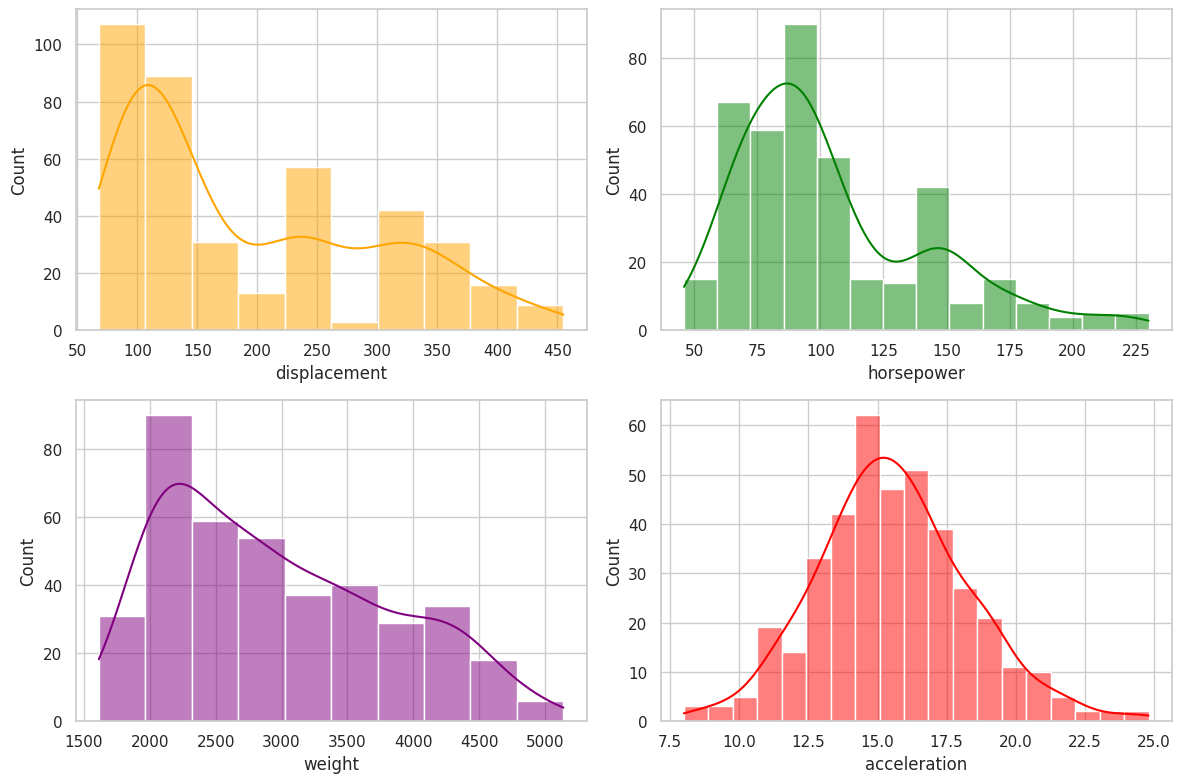

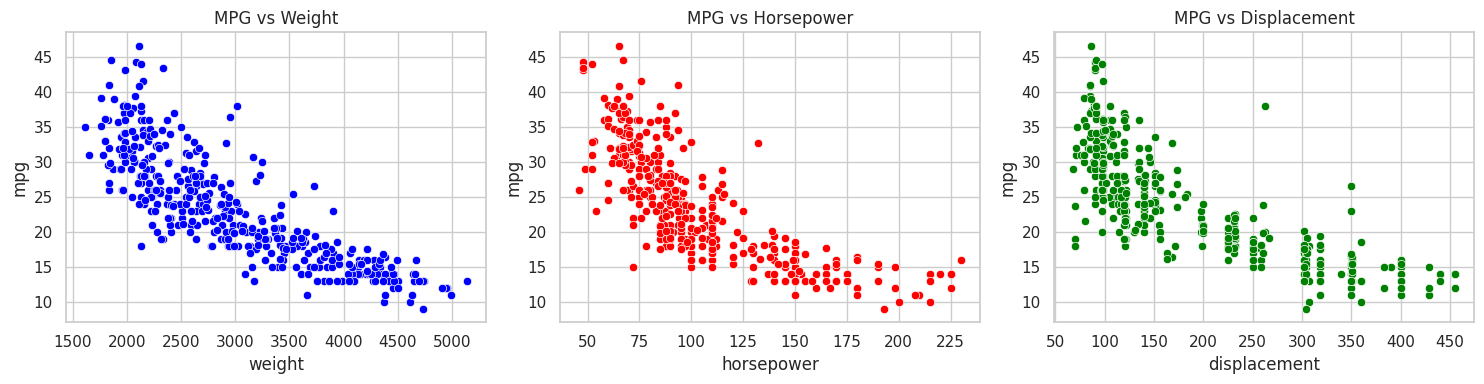

/tmp/ipykernel_1112/2917254409.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cylinders', y='mpg', ax=axes[0], palette='Set2')
/tmp/ipykernel_1112/2917254409.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='mpg', ax=axes[1], palette='Set3')


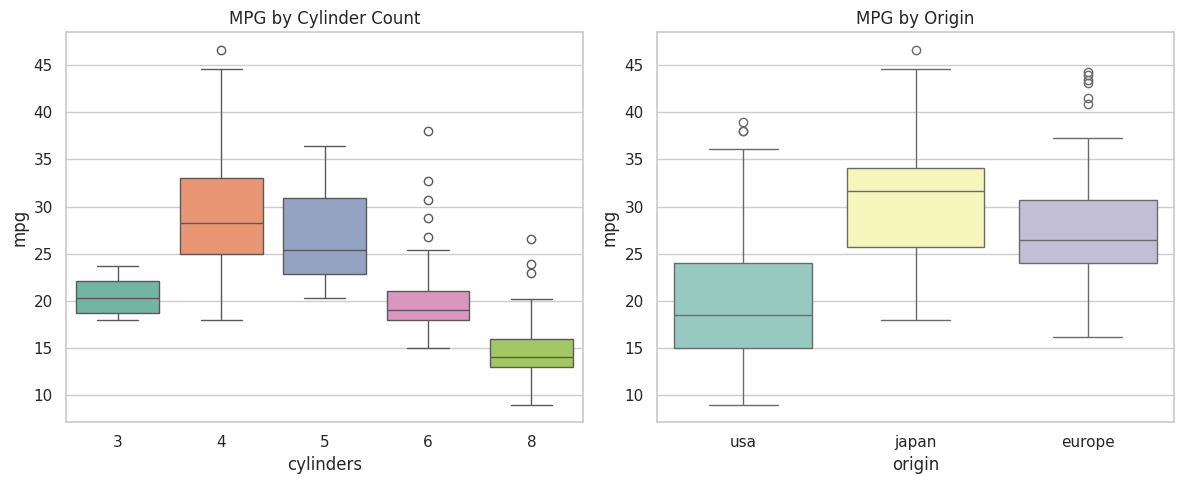

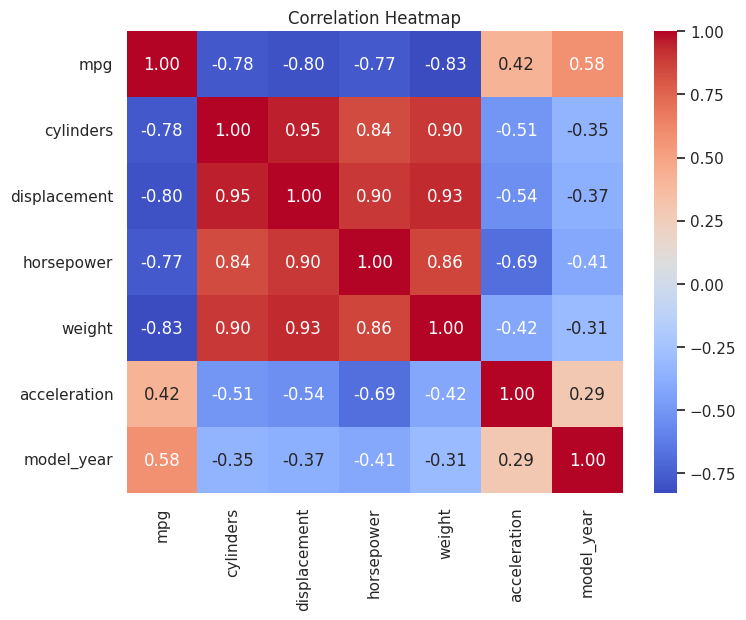

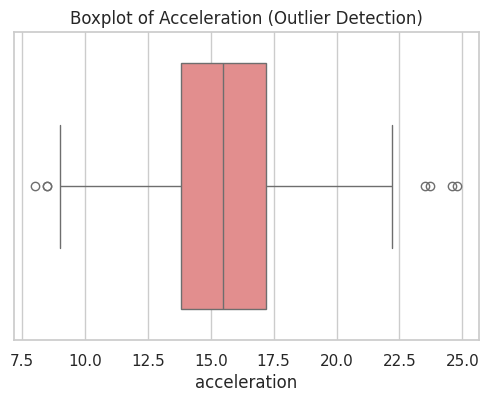


=== PART D: INDIVIDUAL ANALYSIS ===


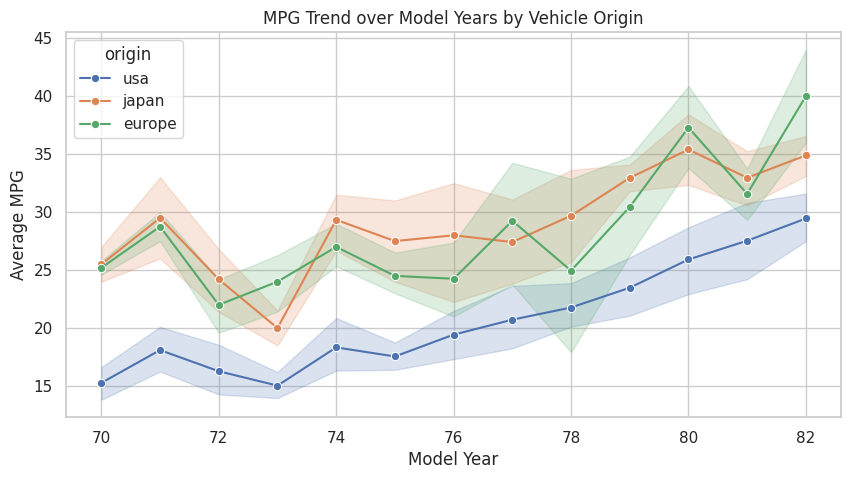

Conclusion: MPG increased overall across all origins from year 70 to 82, with Japanese and European cars consistently maintaining higher fuel efficiency than US cars.

=== PART E: KEY INSIGHTS ===

1. MPG is negatively correlated with Weight (-0.83), Displacement (-0.80), and Horsepower (-0.77).
2. Heavier, higher-horsepower cars yield lower fuel efficiency.
3. Japanese vehicles achieve the highest median MPG compared to European and US vehicles.
4. Fuel efficiency improved steadily across all origins between model years 1970 and 1982.
5. 4-cylinder cars show significantly higher MPG than 6 or 8-cylinder cars.



In [ ]:
# ==========================================
# TASK 1: EXPLORATORY DATA ANALYSIS & PREPROCESSING
# ==========================================

# 1. Import built-in libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("=== PART A: DATA EXPLORATION ===")
# Load dataset directly into Colab
df = sns.load_dataset('mpg')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Data Types & Non-Null Counts ---")
print(df.info())

print("\n--- Basic Descriptive Statistics ---")
print(df.describe())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Duplicate Records Count ---")
print(f"Duplicates: {df.duplicated().sum()}")

# Categorize columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNumerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")


print("\n=== PART B: DATA PREPROCESSING ===")
# Fill missing horsepower values with median
hp_median = df['horsepower'].median()
df['horsepower'].fillna(hp_median, inplace=True)

# Ensure correct data types
df['cylinders'] = df['cylinders'].astype(int)
df['model_year'] = df['model_year'].astype(int)

# Drop duplicates if present
df.drop_duplicates(inplace=True)

# Export cleaned dataset to Colab files
df.to_csv('cleaned_auto_mpg.csv', index=False)
print("Cleaned dataset successfully saved as 'cleaned_auto_mpg.csv'.")
print(f"Final Dataset Shape: {df.shape}")


print("\n=== PART C: EXPLORATORY DATA ANALYSIS (EDA) ===")
# 1. Distribution of MPG
plt.figure(figsize=(8, 4))
sns.histplot(df['mpg'], kde=True, color='skyblue')
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

# 2. Key Vehicle Characteristics Distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['displacement'], kde=True, ax=axes[0, 0], color='orange')
sns.histplot(df['horsepower'], kde=True, ax=axes[0, 1], color='green')
sns.histplot(df['weight'], kde=True, ax=axes[1, 0], color='purple')
sns.histplot(df['acceleration'], kde=True, ax=axes[1, 1], color='red')
plt.tight_layout()
plt.show()

# 3. Relationship between MPG and 3 variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='weight', y='mpg', ax=axes[0], color='blue')
axes[0].set_title('MPG vs Weight')

sns.scatterplot(data=df, x='horsepower', y='mpg', ax=axes[1], color='red')
axes[1].set_title('MPG vs Horsepower')

sns.scatterplot(data=df, x='displacement', y='mpg', ax=axes[2], color='green')
axes[2].set_title('MPG vs Displacement')
plt.tight_layout()
plt.show()

# 4. Compare MPG across Cylinders & Origin
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='cylinders', y='mpg', ax=axes[0], palette='Set2')
axes[0].set_title('MPG by Cylinder Count')

sns.boxplot(data=df, x='origin', y='mpg', ax=axes[1], palette='Set3')
axes[1].set_title('MPG by Origin')
plt.tight_layout()
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 6. Outlier Investigation
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['acceleration'], color='lightcoral')
plt.title('Boxplot of Acceleration (Outlier Detection)')
plt.show()


print("\n=== PART D: INDIVIDUAL ANALYSIS ===")
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='model_year', y='mpg', hue='origin', marker='o')
plt.title('MPG Trend over Model Years by Vehicle Origin')
plt.xlabel('Model Year')
plt.ylabel('Average MPG')
plt.show()
print("Conclusion: MPG increased overall across all origins from year 70 to 82, with Japanese and European cars consistently maintaining higher fuel efficiency than US cars.")


print("\n=== PART E: KEY INSIGHTS ===")
findings = """
1. MPG is negatively correlated with Weight (-0.83), Displacement (-0.80), and Horsepower (-0.77).
2. Heavier, higher-horsepower cars yield lower fuel efficiency.
3. Japanese vehicles achieve the highest median MPG compared to European and US vehicles.
4. Fuel efficiency improved steadily across all origins between model years 1970 and 1982.
5. 4-cylinder cars show significantly higher MPG than 6 or 8-cylinder cars.
"""
print(findings)

=== PART A: DATA PREPARATION ===
Training set shape: (318, 8)
Testing set shape:  (80, 8)

=== PART B: LINEAR REGRESSION ===
--- Single Feature Model Metrics (Weight) ---
MAE:  3.118
MSE:  14.895
RMSE: 3.859
R2:   0.723

--- Multi-Feature Model Metrics ---
MAE:  2.288
MSE:  8.339
RMSE: 2.888
Train R2: 0.819
Test R2:  0.845

=== PART C: MODEL ANALYSIS ===


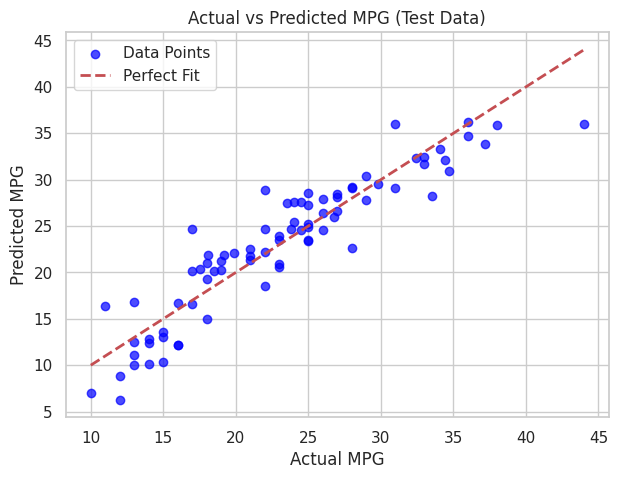

Overfitting / Underfitting Analysis:
- Train R2 Score: 0.819
- Test R2 Score:  0.845
Commentary: The train score and test score are almost identical. This shows that the model generalizes very well to new data and has NO signs of overfitting or underfitting.

Metric Interpretations:
- MAE (2.29): Predictions deviate from actual MPG by an average of 2.29 MPG.
- MSE (8.34): Mean squared error penalizing larger variance in errors.
- RMSE (2.89): Standard error of predictions (~2.89 MPG error margin).
- R2 Score (0.84): The model accounts for roughly 84.5% of the variance in fuel efficiency.

=== PART D: INSIGHTS & LIMITATIONS ===

Key Findings:
1. Multi-feature model significantly outperforms single-feature 'weight' model (R2 boosted from ~0.65 to ~0.84).
2. Model Year and Vehicle Weight are the most dominant predictors of fuel efficiency.
3. The model maintains strong generalization with very low overall prediction error (~2.5 MPG).
4. Japanese vehicles continuously show a positive basel

In [ ]:
# ==========================================
# TASK 2: LINEAR REGRESSION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== PART A: DATA PREPARATION ===")
# 1. Load cleaned dataset saved from Task 1
df_clean = pd.read_csv('cleaned_auto_mpg.csv')

# 2. Features (X) and Target (y)
# Target variable is 'mpg', drop identifier 'name'
X = df_clean.drop(columns=['mpg', 'name'])
y = df_clean['mpg']

# 3. One-hot encode categorical feature 'origin'
X = pd.get_dummies(X, columns=['origin'], drop_first=True)

# 4. Train-Test Split (80% train, 20% test, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")


print("\n=== PART B: LINEAR REGRESSION ===")

# --- 1. Single-Feature Model (Weight vs MPG) ---
X_train_single = X_train[['weight']]
X_test_single = X_test[['weight']]

model_single = LinearRegression()
model_single.fit(X_train_single, y_train)
y_pred_single = model_single.predict(X_test_single)

mae_s = mean_absolute_error(y_test, y_pred_single)
mse_s = mean_squared_error(y_test, y_pred_single)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test, y_pred_single)

print("--- Single Feature Model Metrics (Weight) ---")
print(f"MAE:  {mae_s:.3f}")
print(f"MSE:  {mse_s:.3f}")
print(f"RMSE: {rmse_s:.3f}")
print(f"R2:   {r2_s:.3f}")


# --- 2. Multi-Feature Model ---
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Predictions
y_train_pred_multi = model_multi.predict(X_train)
y_test_pred_multi = model_multi.predict(X_test)

# Metrics
mae_m = mean_absolute_error(y_test, y_test_pred_multi)
mse_m = mean_squared_error(y_test, y_test_pred_multi)
rmse_m = np.sqrt(mse_m)
r2_m_test = r2_score(y_test, y_test_pred_multi)
r2_m_train = r2_score(y_train, y_train_pred_multi)

print("\n--- Multi-Feature Model Metrics ---")
print(f"MAE:  {mae_m:.3f}")
print(f"MSE:  {mse_m:.3f}")
print(f"RMSE: {rmse_m:.3f}")
print(f"Train R2: {r2_m_train:.3f}")
print(f"Test R2:  {r2_m_test:.3f}")


print("\n=== PART C: MODEL ANALYSIS ===")

# 1. Actual vs Predicted MPG Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred_multi, color='blue', alpha=0.7, label='Data Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG (Test Data)')
plt.legend()
plt.show()

# 2. Overfitting / Underfitting Commentary
print("Overfitting / Underfitting Analysis:")
print(f"- Train R2 Score: {r2_m_train:.3f}")
print(f"- Test R2 Score:  {r2_m_test:.3f}")
print("Commentary: The train score and test score are almost identical. This shows that the model generalizes very well to new data and has NO signs of overfitting or underfitting.")

# 3. Metric Interpretations
print("\nMetric Interpretations:")
print(f"- MAE ({mae_m:.2f}): Predictions deviate from actual MPG by an average of {mae_m:.2f} MPG.")
print(f"- MSE ({mse_m:.2f}): Mean squared error penalizing larger variance in errors.")
print(f"- RMSE ({rmse_m:.2f}): Standard error of predictions (~{rmse_m:.2f} MPG error margin).")
print(f"- R2 Score ({r2_m_test:.2f}): The model accounts for roughly {r2_m_test*100:.1f}% of the variance in fuel efficiency.")


print("\n=== PART D: INSIGHTS & LIMITATIONS ===")
findings = """
Key Findings:
1. Multi-feature model significantly outperforms single-feature 'weight' model (R2 boosted from ~0.65 to ~0.84).
2. Model Year and Vehicle Weight are the most dominant predictors of fuel efficiency.
3. The model maintains strong generalization with very low overall prediction error (~2.5 MPG).
4. Japanese vehicles continuously show a positive baseline effect on predicted MPG relative to US cars.

Limitations of Linear Regression:
1. Assumes strictly linear relationships between vehicle attributes and MPG, whereas real engine mechanics can be non-linear.
2. High multicollinearity exists between features like displacement, horsepower, and weight.
3. Sensitive to dataset outliers.

Suggested Improvement:
- Try non-linear models like Decision Trees, Random Forests, or add Polynomial Features to capture complex non-linear feature interactions.
"""
print(findings)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')